In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree
from scipy.spatial.distance import pdist

# Hierarchical clustering

In [2]:
df = pd.read_csv('USArrests.csv', index_col = 0)
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


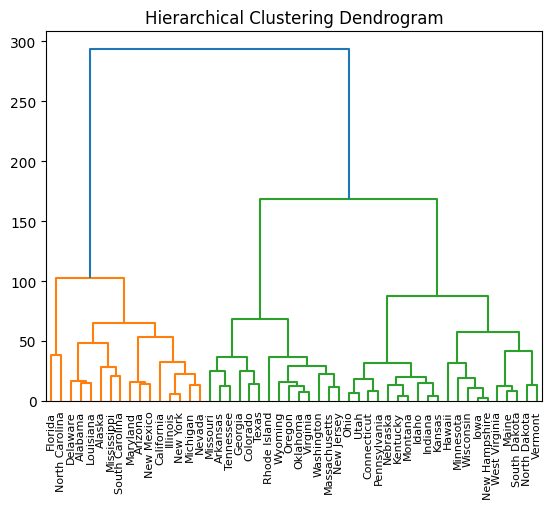

In [3]:
# Hierarchical clustering
clusters = linkage(pdist(df, metric = 'euclidean'), method = 'complete')

# Basic plot of hierarchical clustering
dendrogram(clusters, labels = df.index)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

[2 2 2 3 2 3 4 2 1 3 4 4 2 4 4 4 4 2 4 2 3 2 4 2 3 4 4 2 4 3 2 2 1 4 4 3 3
 4 3 2 4 3 3 4 4 3 3 4 4 3]


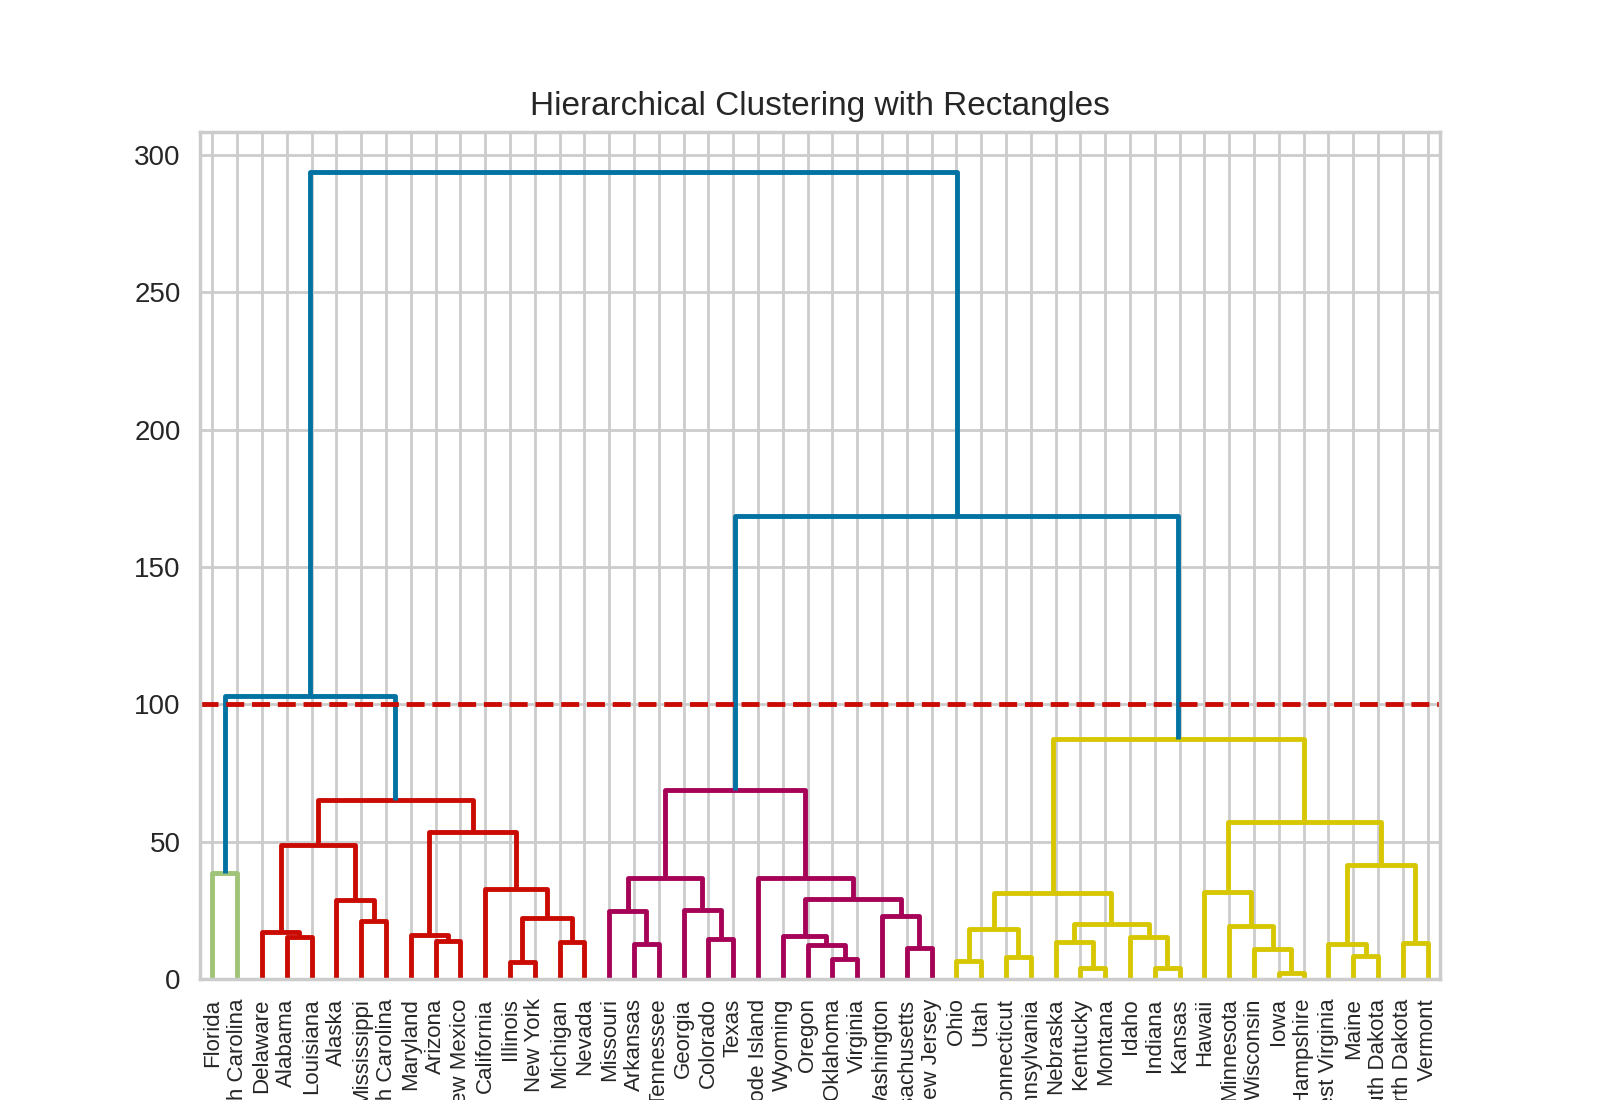

In [ ]:
# Cutting the dendrogram to form flat clusters
dendrogram(clusters, labels = df.index,
           color_threshold = 100)
plt.title('Hierarchical Clustering with Rectangles')
plt.axhline(y = 100,
            color = 'r',
            linestyle = '--')  # draw a line to cut at height 100
clusters_cut = cut_tree(clusters, n_clusters = 4).reshape(-1, )
print(clusters_cut)

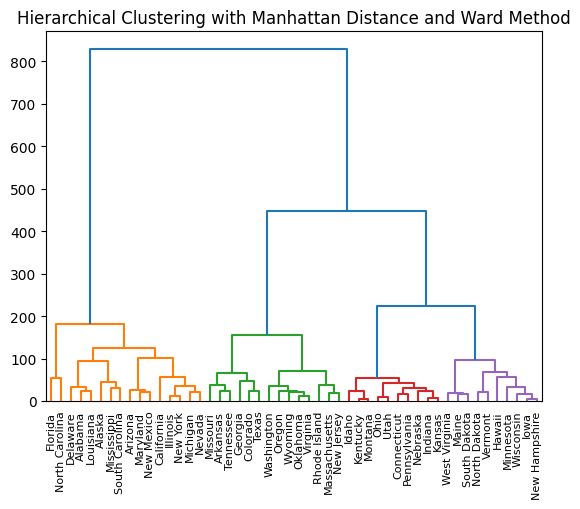

In [5]:
# Manhattan distance and Ward method
clusters_manhattan = linkage(pdist(df, metric = 'cityblock'),
                             method = 'ward')

# Plot for Manhattan distance with Ward method)
dendrogram(clusters_manhattan,
           labels = df.index,
           color_threshold = 200)
plt.title('Hierarchical Clustering with Manhattan Distance and Ward Method')
plt.show()

# k-means

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale

kmeans = KMeans(n_clusters = 4,
                n_init = 1000)
clusters = kmeans.fit_predict(df)
print(clusters)

[2 2 2 0 2 0 3 2 2 0 1 3 2 3 1 3 3 2 1 2 0 2 1 2 0 3 3 2 1 0 2 2 2 1 3 0 0
 3 0 2 1 0 0 3 1 0 0 1 1 0]


Caliński-Harabasz Score: 141.762
Average Silhouette Score: 0.501
Sample Silhouette Scores: [0.28345203 0.5488599  0.65695328 0.54098346 0.6062158  0.4098906
 0.67117967 0.31391057 0.55744099 0.28794873 0.40899075 0.67357945
 0.49543573 0.76241929 0.62860856 0.77520472 0.62641548 0.51304855
 0.19363416 0.65812756 0.15364534 0.57857461 0.36211054 0.51432511
 0.60067072 0.64899996 0.61807262 0.49921114 0.62784765 0.37387412
 0.67812069 0.53725106 0.53243628 0.59210952 0.68336358 0.23985086
 0.42290604 0.69126861 0.48436569 0.62361484 0.10072159 0.59010962
 0.48617098 0.62537917 0.53592288 0.35852354 0.02296893 0.27677455
 0.57799094 0.41218137]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


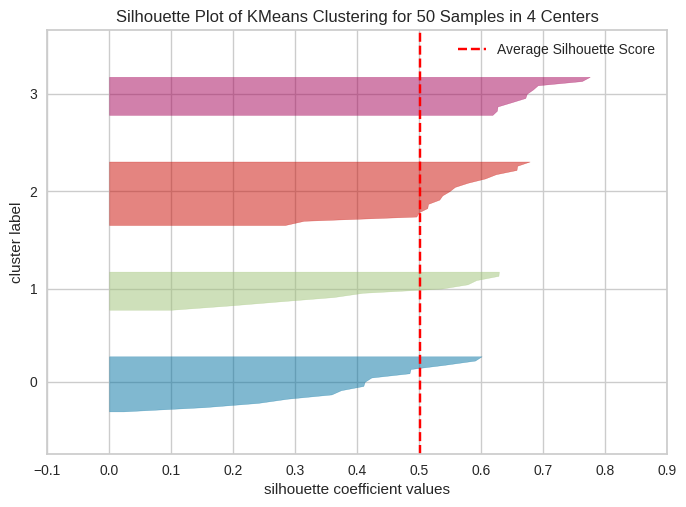

In [7]:
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score
from yellowbrick.cluster import silhouette_visualizer

ch_score = calinski_harabasz_score(df, clusters)
print(f"Caliński-Harabasz Score: {np.round(ch_score, 3)}")

s_score = silhouette_score(df, clusters)
print(f"Average Silhouette Score: {np.round(s_score, 3)}")

sample_silhouette_values = silhouette_samples(df, clusters)
print(f"Sample Silhouette Scores: {sample_silhouette_values}")

silhouette_visualizer(kmeans, df, colors = 'yellowbrick');

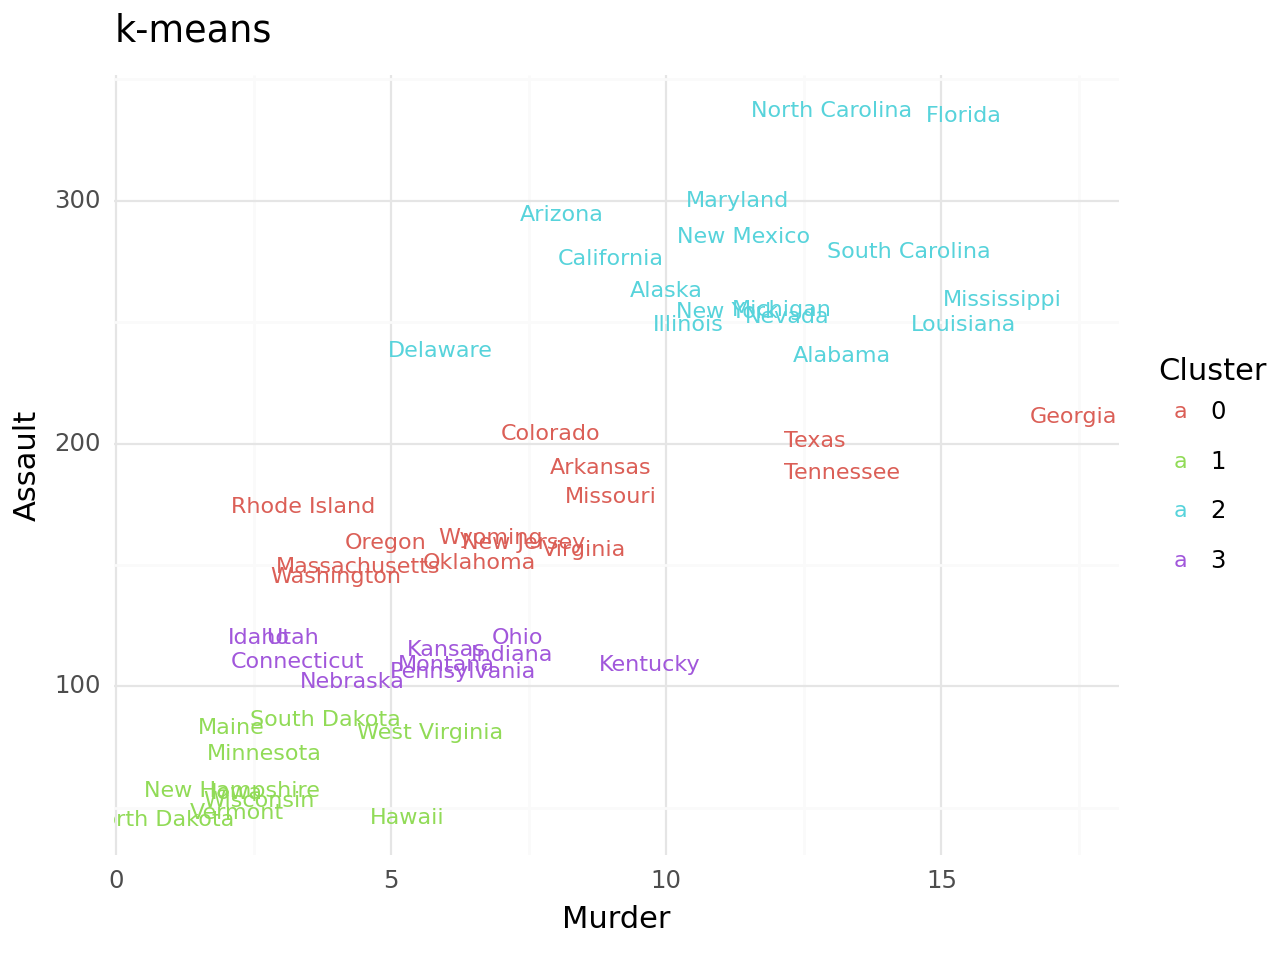

<Figure Size: (640 x 480)>

In [9]:
from plotnine import ggplot, aes, geom_text, labs, theme_minimal, guides, guide_legend

df['Cluster'] = clusters
df['State'] = df.index

(
    ggplot(df, aes(x = 'Murder',
                   y = 'Assault',
                   color = 'factor(Cluster)',
                   label = 'State'))
    +geom_text(size = 8)
    +labs(title = 'k-means',
         x = 'Murder',
         y = 'Assault')
    +guides(color = guide_legend(title = "Cluster"))
    +theme_minimal()
)

In [10]:
df.drop(['State', 'Cluster'], axis = 1, inplace = True)

# Partitioning Around Medoids (PAM)

In [11]:
!pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 16.0 MB/s eta 0:00:00


In [12]:
from sklearn.preprocessing import scale
from sklearn_extra.cluster import KMedoids

scaled_data = scale(df)

# Perform K-Medoids clustering with 4 clusters
kmedoids = KMedoids(n_clusters = 4)
kmedoids.fit(scaled_data)

print("Cluster Labels:", kmedoids.labels_)
print("Medoids Indices:", kmedoids.medoid_indices_)

Cluster Labels: [1 1 1 2 1 1 2 2 1 1 2 3 1 2 3 2 2 1 3 1 0 1 3 1 0 2 2 1 3 0 1 1 1 3 2 2 0
 2 2 1 3 1 1 0 3 2 0 3 3 2]
Medoids Indices: [46 30 15 28]


# DBSCAN

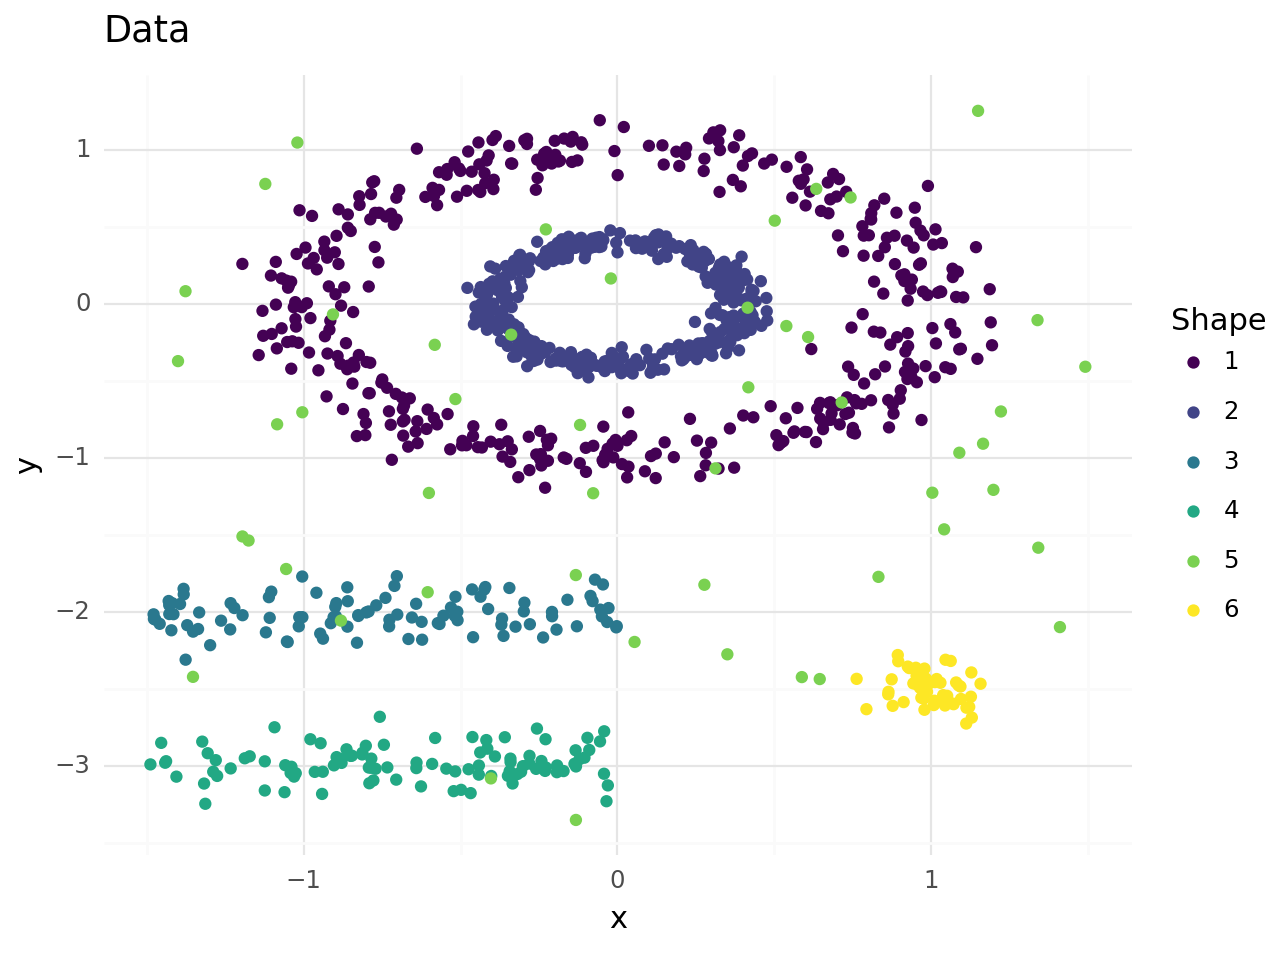

<Figure Size: (640 x 480)>

In [13]:
# Data containing clusters of any shapes.
df = pd.read_csv('multishapes.csv')
df.head()

(
    ggplot(df, aes(x = 'x',
                   y = 'y',
                   color = 'shape'))
    +geom_point()
    +labs(title = 'Data',
         x = 'x',
         y = 'y')
    +guides(color = guide_legend(title = "Shape"))
    +theme_minimal()
)

In [14]:
kmeans = KMeans(n_clusters = 5)
df['clustersKMeans'] = kmeans.fit_predict(df)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning


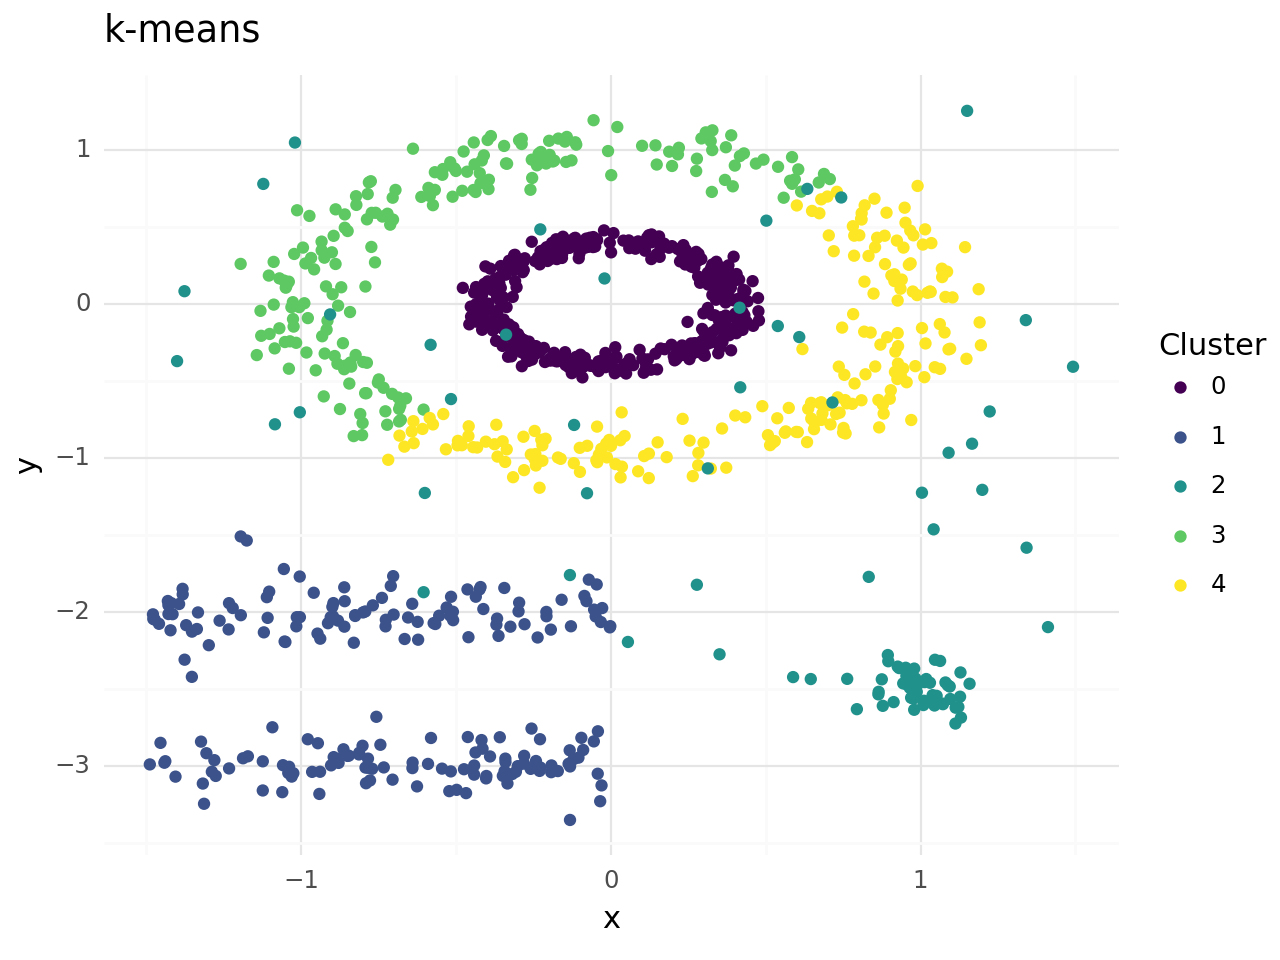

<Figure Size: (640 x 480)>

In [15]:
(
    ggplot(df, aes(x = 'x',
                   y = 'y',
                   color = 'clustersKMeans'))
    +geom_point()
    +labs(title = 'k-means',
         x = 'x',
         y = 'y')
    +guides(color = guide_legend(title = "Cluster"))
    +theme_minimal()
)

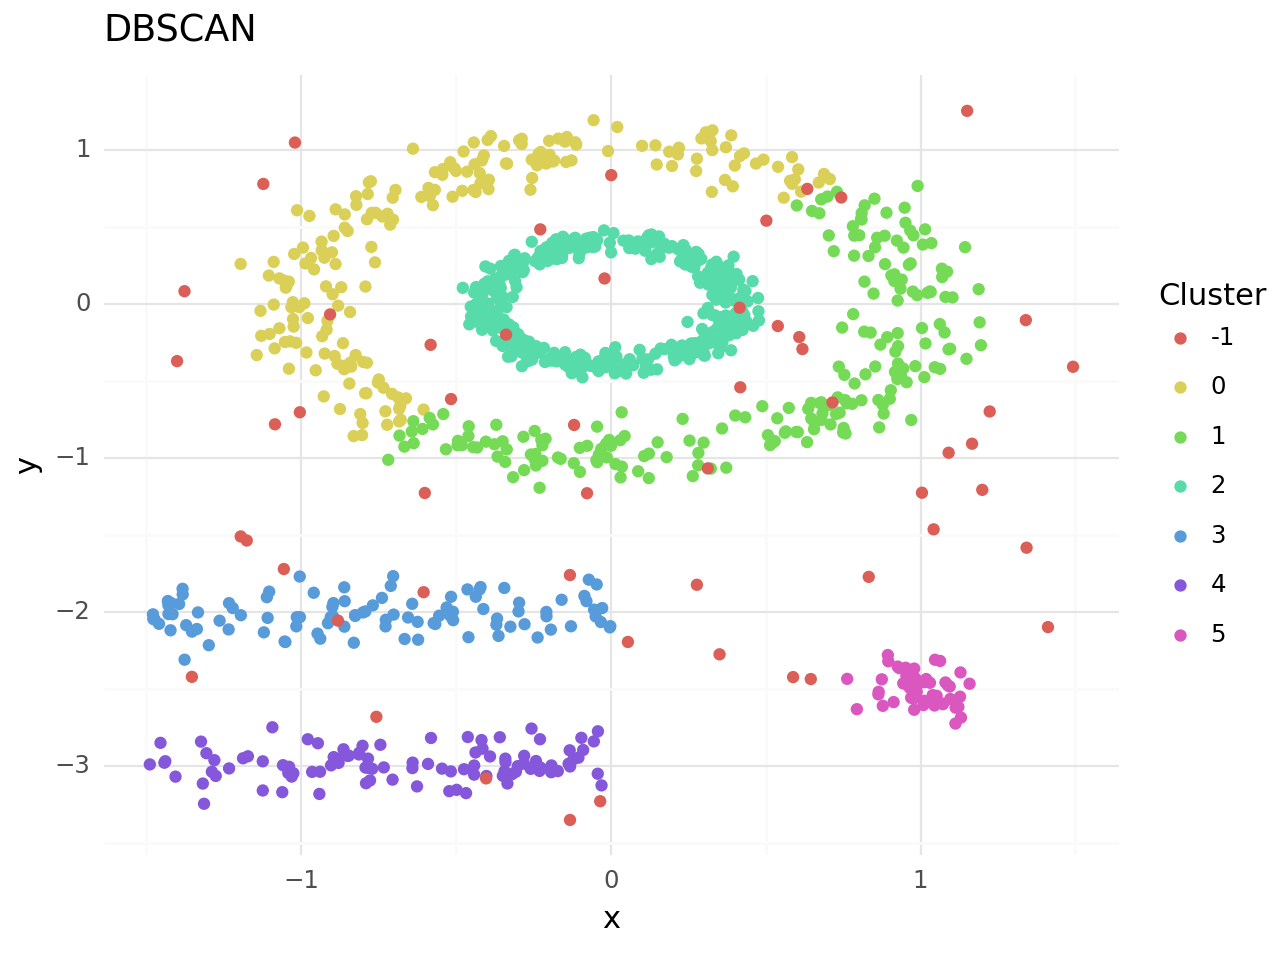

<Figure Size: (640 x 480)>

In [22]:
from sklearn.cluster import DBSCAN

# DBSCAN Clustering
dbscan = DBSCAN(eps = 0.15,
                min_samples = 5)
df['clustersDBSCAN'] = dbscan.fit_predict(df)

(
    ggplot(df, aes(x = 'x',
                   y = 'y',
                   color = 'factor(clustersDBSCAN)'))
    +geom_point()
    +labs(title = 'DBSCAN',
         x = 'x',
         y = 'y')
    +guides(color = guide_legend(title = "Cluster"))
    +theme_minimal()
)

In [ ]:
df.drop(['clustersKMeans', 'clustersDBSCAN'], axis = 1, inplace = True)

In [23]:
from sklearn.neighbors import NearestNeighbors

# Calculate the distances to the nearest points (for each point)
neigh = NearestNeighbors(n_neighbors = 5)
nbrs = neigh.fit(df)
distances, indices = nbrs.kneighbors(df)

# Sort distances
distances = np.sort(distances, axis = 0)
distances = distances[:, 1]  # Take the distance to the nearest neighbor

df_dist = pd.DataFrame(distances, columns = ['dist'])
df_dist['x'] = list(range(1, len(df_dist) + 1, 1))
print(df_dist)

          dist     x
0     0.001548     1
1     0.001548     2
2     0.001565     3
3     0.001565     4
4     0.001632     5
...        ...   ...
1095  0.694261  1096
1096  0.907425  1097
1097  0.907425  1098
1098  1.012232  1099
1099  1.630441  1100

[1100 rows x 2 columns]


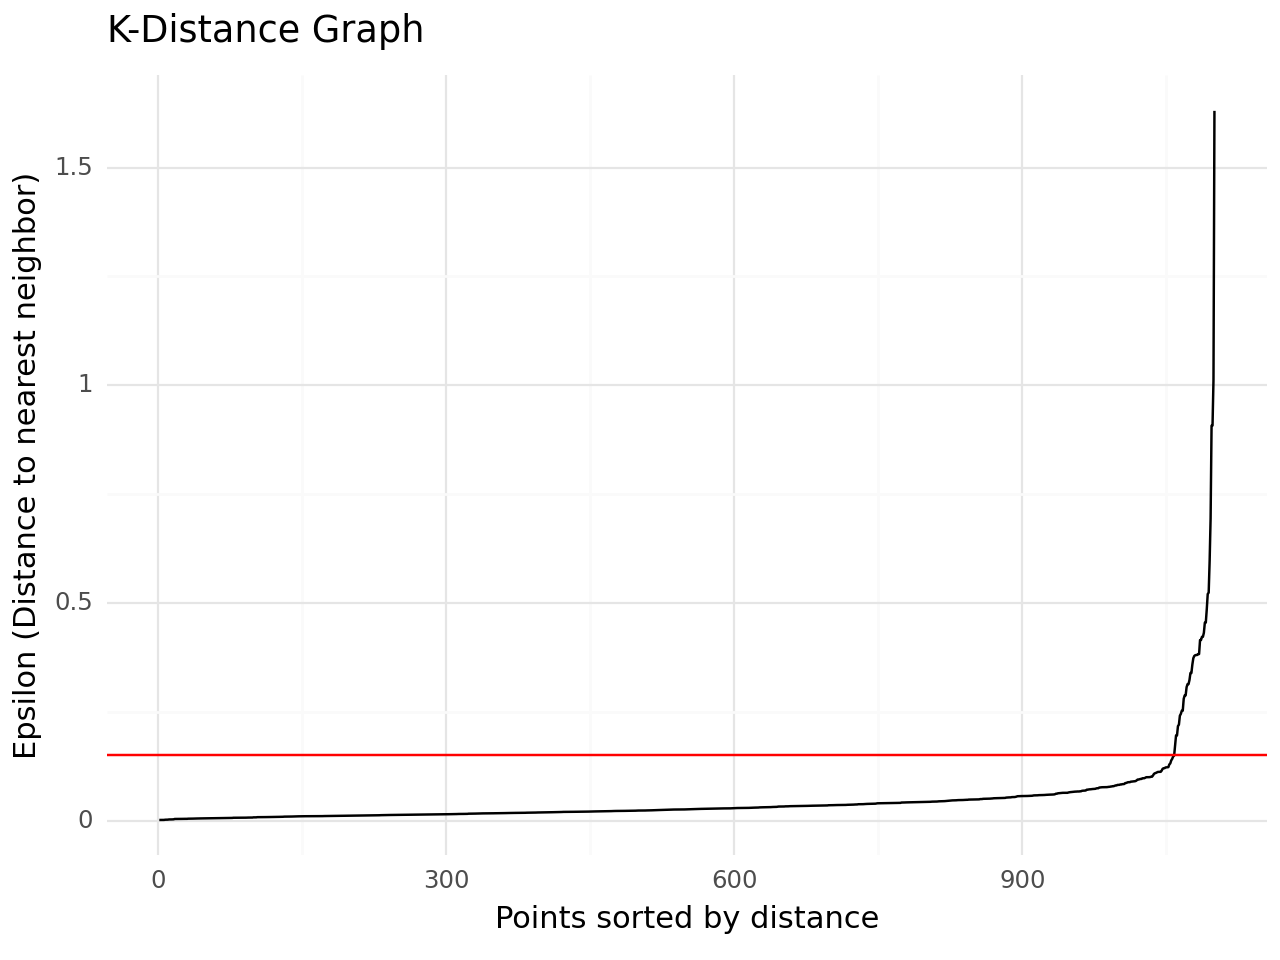

<Figure Size: (640 x 480)>

In [24]:
from plotnine import geom_hline, geom_line

(
    ggplot(df_dist, aes(x = 'x', y = 'dist'))
    +geom_line()
    +geom_hline(aes(yintercept = 0.15), color = 'red')
    +labs(title = 'K-Distance Graph',
         x = 'Points sorted by distance',
         y = 'Epsilon (Distance to nearest neighbor)')
    +theme_minimal()
)

# Exercice 1 (30 minutes)

The dataset `votes_repub` contains information on the percentage of votes cast for Republicans in the U.S. presidential elections from 1856 to 1976. Using the Manhattan distance as a measure of dissimilarity and the complete linkage method, perform hierarchical clustering on this dataset. Draw a dendrogram. Which number of clusters seems most sensible? Then, in the layout of the first two principal components, visualize the results (points corresponding to different states should have the same color if they belong to the same cluster). Try to add the names of the states to the plot.

S. Peterson (1973): A Statistical History of the American Presidential Elections. New York: Frederick Ungar Publishing Co.